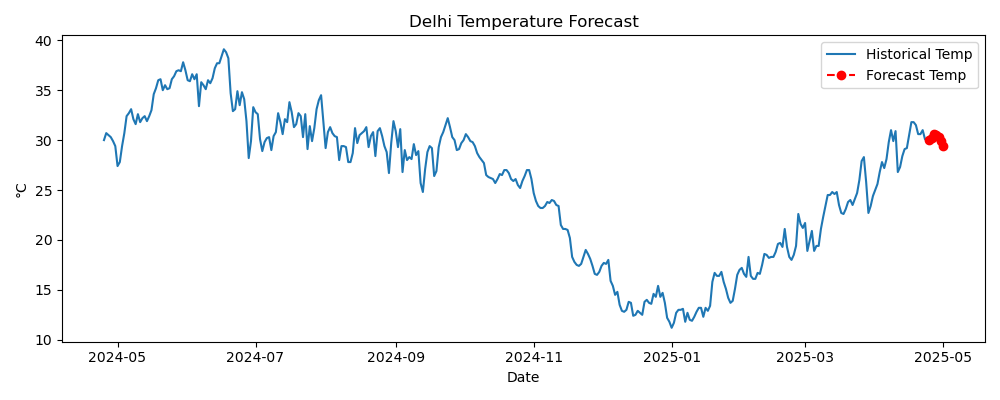

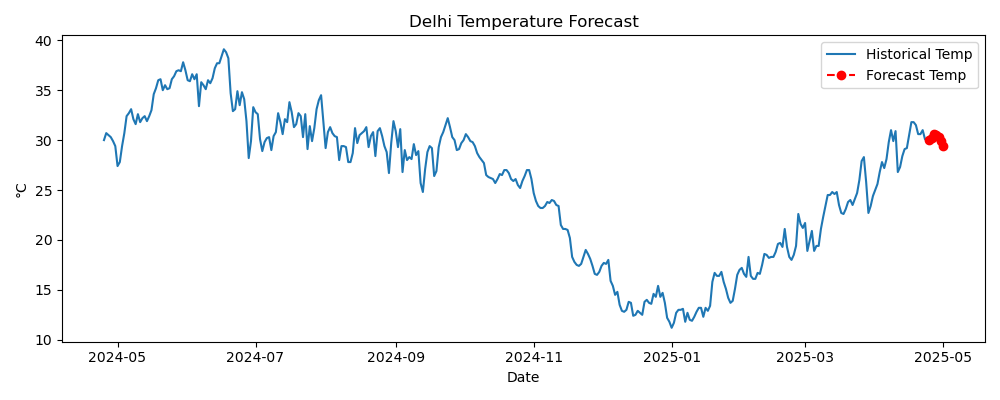

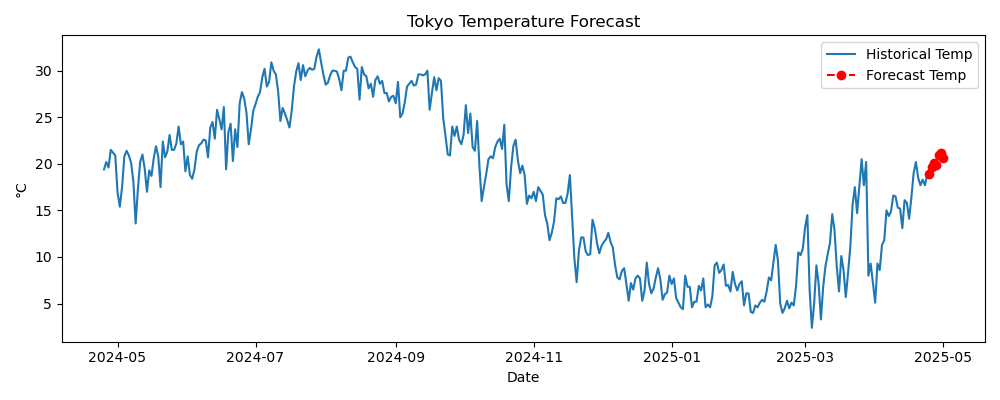

In [ ]:
from tkinter import *
from datetime import datetime, timedelta
from meteostat import Point, Daily
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from IPython.display import Image, display  

root = Tk()
root.geometry("1450x1000")
root.configure(bg='lightblue')
root.title("7-Day Weather Forecast")

city_value = StringVar()

# Coordinates of supported cities
city_coords = {
    "Delhi": (28.6139, 77.2090),
    "New York": (40.7128, -74.0060),
    "London": (51.5074, -0.1278),
    "Tokyo": (35.6762, 139.6503),
    "Mumbai": (19.0760, 72.8777)
}

# Fetch historical weather data
def fetch_historical_data(city_name):
    if city_name not in city_coords:
        raise ValueError("City not supported.")
    
    lat, lon = city_coords[city_name]
    location = Point(lat, lon)
    end = datetime.now()
    start = end - timedelta(days=365)

    data = Daily(location, start, end).fetch().reset_index()
    data['dayofyear'] = data['time'].dt.dayofyear
    return data

# Train a RandomForest model to forecast temperature or precipitation
def train_model(data, feature):
    if feature not in data.columns:
        return None
    train_data = data[['dayofyear', feature]].dropna()
    if train_data.empty:
        return None
    X = train_data[['dayofyear']]
    y = train_data[feature]
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model

# Predict the weather for the next 7 days
def predict_next_week(models):
    future_dates = [datetime.now() + timedelta(days=i) for i in range(1, 8)]
    df = pd.DataFrame({'time': future_dates})
    df['dayofyear'] = df['time'].dt.dayofyear
    df['date'] = df['time'].dt.strftime('%Y-%m-%d')

    preds = {}
    for feature, model in models.items():
        if model:
            preds[feature] = model.predict(df[['dayofyear']])
    return df['date'], preds

# Provide weather advice based on temperature and precipitation
def weather_advice(temp, precip):
    if precip > 5:
        return "There is a high chance of rain, carry an umbrella."
    elif temp > 30:
        return "There is a chance of rain due to high temperature."
    elif temp < 10:
        return "It is cold, consider bringing a coat."
    elif 15 <= temp <= 25:
        return "The weather is pleasant, great for outdoor activities."
    else:
        return "No major weather concerns detected."

# Show weather information and predictions
def showWeather():
    city_name = city_value.get().strip().title()
    tfield.delete("1.0", "end")
    try:
        data = fetch_historical_data(city_name)
        models = {}
        available = []

        for feature in ['tavg', 'prcp']:  # Only using 'tavg' and 'prcp' for prediction
            model = train_model(data, feature)
            if model:
                models[feature] = model
                available.append(feature)

        if 'tavg' not in models:
            raise ValueError("Temperature data not available for forecasting.")

        dates, preds = predict_next_week(models)

        header = f"\n7-Day Forecast for {city_name}:\n"
        header += "Date       | Temp (°C) "
        if 'prcp' in preds:
            header += "| Precip (mm) "
        header += "\n" + "-" * 50 + "\n"

        rows = ""
        for i in range(7):
            row = f"{dates[i]} | {preds['tavg'][i]:10.2f}"
            if 'prcp' in preds:
                row += f" | {preds['prcp'][i]:12.2f}"
            rows += row + "\n"
        
        # Adding weather advice for each day
        advice = ""
        for i in range(7):
            temp = preds['tavg'][i]
            precip = preds['prcp'][i] if 'prcp' in preds else 0
            advice += f"Day {i+1} Advice: {weather_advice(temp, precip)}\n"

        tfield.insert(INSERT, header + rows + advice)

        # Plot temperature forecast
        plt.figure(figsize=(10, 4))
        plt.plot(data['time'], data['tavg'], label='Historical Temp')
        plt.plot(pd.to_datetime(dates), preds['tavg'], 'ro--', label='Forecast Temp')
        plt.title(f"{city_name} Temperature Forecast")
        plt.xlabel("Date")
        plt.ylabel("°C")
        plt.legend()
        plt.tight_layout()
        plt.savefig("forecast.png")

        # Display the saved plot in Jupyter Notebook
        display(Image(filename="forecast.png"))

    except Exception as e:
        tfield.insert(INSERT, f"Error: {e}\nSupported cities: {', '.join(city_coords.keys())}")

# GUI Layout
Label(root, text='Enter City Name (e.g. Delhi):', font='Arial 40 bold').pack(pady=10)
Entry(root, textvariable=city_value, width=40, font='Arial 40 bold').pack()
Button(root, command=showWeather, text="Forecast Weather", font="Arial 20", bg='lightblue').pack(pady=20)
Label(root, text="Forecast Output:", font='Arial 40 bold').pack(pady=20)

tfield = Text(root, width=133, height=18)
tfield.pack()

root.mainloop()